# DCGAN — ArtBench-10 (Dataset Completo / 100%)

**Versão "full"** do notebook `2_dcgan_artbench.ipynb`.

Diferenças em relação à versão original (subset 20%):
- **Dataset**: 50K imagens (full train) em vez de 10K (subset 20%)
- **Épocas**: 60 (em vez de 200) — mantém aproximadamente o mesmo número de *gradient steps* (~15.6K steps no original vs ~23.4K aqui), comparação justa
- **Checkpoints**: guardados como `dcgan_G_artbench_full.pt` e `dcgan_D_artbench_full.pt` (os originais mantêm-se intactos)

Tudo o resto (arquitectura, Z_DIM=100, NGF=64, NDF=64, lr=0.0002, beta1=0.5, label smoothing) é **idêntico** à versão original.


In [1]:
import sys
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── auto-detecção do PROJECT_ROOT ─────────────────────────────────
# O CWD no VS Code Jupyter pode ser o workspace root OU a pasta do notebook.
# Este código testa as duas possibilidades.
_cwd = Path(os.path.abspath(''))
if (_cwd / 'scripts').exists():
    PROJECT_ROOT = _cwd            # CWD já é o root (ex: STUDENT_STARTER_PACK/)
elif (_cwd.parent / 'scripts').exists():
    PROJECT_ROOT = _cwd.parent     # CWD é student_start_pack/, scripts está um nível acima
else:
    raise RuntimeError(f"Não encontrei a pasta 'scripts'.\nCWD: {_cwd}\nVerifica a estrutura do projecto.")

SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("PROJECT_ROOT :", PROJECT_ROOT)
print("SCRIPTS_DIR  :", SCRIPTS_DIR,  "| existe?", SCRIPTS_DIR.exists())
print("KAGGLE_ROOT  :", KAGGLE_ROOT,   "| existe?", KAGGLE_ROOT.exists())

# ── reproducibilidade ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── device ────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

PROJECT_ROOT : c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack
SCRIPTS_DIR  : c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\scripts | existe? True
KAGGLE_ROOT  : c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\ArtBench-10 | existe? True
Device: cuda


In [2]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds    = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

IMAGE_SIZE = 32
BATCH_SIZE = 64

# transform: normaliza para [-1, 1] (importante para Tanh no Generator!)
transform = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        ex = self.ds[self.indices[idx]]
        img = ex["image"]
        y   = int(ex["label"])
        x   = self.transform(img) if self.transform else img
        return x, y

# ── DATASET COMPLETO (50K imagens, 100%) ──────────────────────────
# Diferença vs notebook original: NÃO filtramos pelo CSV de 20%.
train_ds     = HFDatasetTorch(train_hf, transform=transform)   # 100% (50K)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print(f"Train: {len(train_ds)} imagens | Batches/epoch: {len(train_loader)}")

Dataset source: kaggle root='c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\ArtBench-10'
Train: 50000 imagens | Batches/epoch: 782


In [3]:
Z_DIM = 100  # dimensão do ruído de entrada
NGF   = 64   # tamanho base de filtros do Generator
NDF   = 64   # tamanho base de filtros do Discriminator

class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, ngf=NGF):
        super().__init__()
        self.net = nn.Sequential(
            # z → 4×4
            nn.ConvTranspose2d(z_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            # 4 → 8
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            # 8 → 16
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            # 16 → 32
            nn.ConvTranspose2d(ngf*2, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # saída em [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, ndf=NDF):
        super().__init__()
        self.net = nn.Sequential(
            # 32 → 16
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 16 → 8
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            # 8 → 4
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            # 4 → 1
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # probabilidade real/fake
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    """Inicialização de pesos recomendada para DCGAN"""
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

# teste de shapes
z_test = torch.randn(4, Z_DIM, 1, 1).to(device)
fake   = G(z_test)
score  = D(fake)
print("G output:", fake.shape)   # [4, 3, 32, 32]
print("D output:", score.shape)  # [4]

G output: torch.Size([4, 3, 32, 32])
D output: torch.Size([4])


In [4]:
def train_dcgan(G, D, loader, epochs=50, lr=0.0002, beta1=0.5):
    criterion  = nn.BCELoss()
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

    # ruído fixo para ver evolução das amostras ao longo do treino
    fixed_z = torch.randn(64, Z_DIM, 1, 1).to(device)
    history = []

    for ep in range(epochs):
        g_total, d_total = 0., 0.

        for real, _ in tqdm(loader, desc=f"Epoch {ep+1}/{epochs}", leave=False):
            real = real.to(device)
            b    = real.size(0)

            # ── Treinar Discriminator ──────────────────────────
            D.zero_grad()
            # real: labels = 0.9 (label smoothing → mais estável)
            label_real = torch.full((b,), 0.9, device=device)
            label_fake = torch.zeros(b, device=device)

            loss_D_real = criterion(D(real), label_real)
            z    = torch.randn(b, Z_DIM, 1, 1).to(device)
            fake = G(z).detach()
            loss_D_fake = criterion(D(fake), label_fake)
            loss_D = loss_D_real + loss_D_fake
            loss_D.backward()
            opt_D.step()

            # ── Treinar Generator ──────────────────────────────
            G.zero_grad()
            z    = torch.randn(b, Z_DIM, 1, 1).to(device)
            fake = G(z)
            # Generator quer enganar o D → labels = 1
            loss_G = criterion(D(fake), torch.ones(b, device=device))
            loss_G.backward()
            opt_G.step()

            g_total += loss_G.item()
            d_total += loss_D.item()

        n = len(loader)
        h = {'loss_G': g_total/n, 'loss_D': d_total/n}
        history.append(h)
        print(f"Epoch {ep+1:02d} | loss_G={h['loss_G']:.4f}  loss_D={h['loss_D']:.4f}")

    return history, fixed_z

In [5]:
# ── Configuração do treino — DATASET COMPLETO ─────────────────────
# Original (subset 20%): EPOCHS=200 com ~156 batches/epoch → ~31.2K steps
# Aqui    (full 100%)  : EPOCHS=60  com ~781 batches/epoch → ~46.9K steps
# Com mais dados o GAN beneficia de mais steps; 60 epochs é conservador mas suficiente.
EPOCHS = 200

history, fixed_z = train_dcgan(G, D, train_loader, epochs=EPOCHS)

# ── Guardar checkpoints com nomes distintos do original ───────────
Path('artifacts').mkdir(exist_ok=True)
torch.save(G.state_dict(), 'artifacts/dcgan_G_artbench_full.pt')
torch.save(D.state_dict(), 'artifacts/dcgan_D_artbench_full.pt')
print("Modelos guardados em artifacts/dcgan_*_artbench_full.pt ✅")

Epoch 1/200:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 01 | loss_G=3.4370  loss_D=0.8139


Epoch 2/200:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 02 | loss_G=2.7968  loss_D=0.8563


Epoch 3/200:   0%|          | 0/782 [00:00<?, ?it/s]

...

Epoch 198 | loss_G=3.6279  loss_D=0.5396


Epoch 199/200:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 199 | loss_G=3.5965  loss_D=0.5424


Epoch 200/200:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 200 | loss_G=3.6002  loss_D=0.5128
Modelos guardados em artifacts/dcgan_*_artbench_full.pt ✅


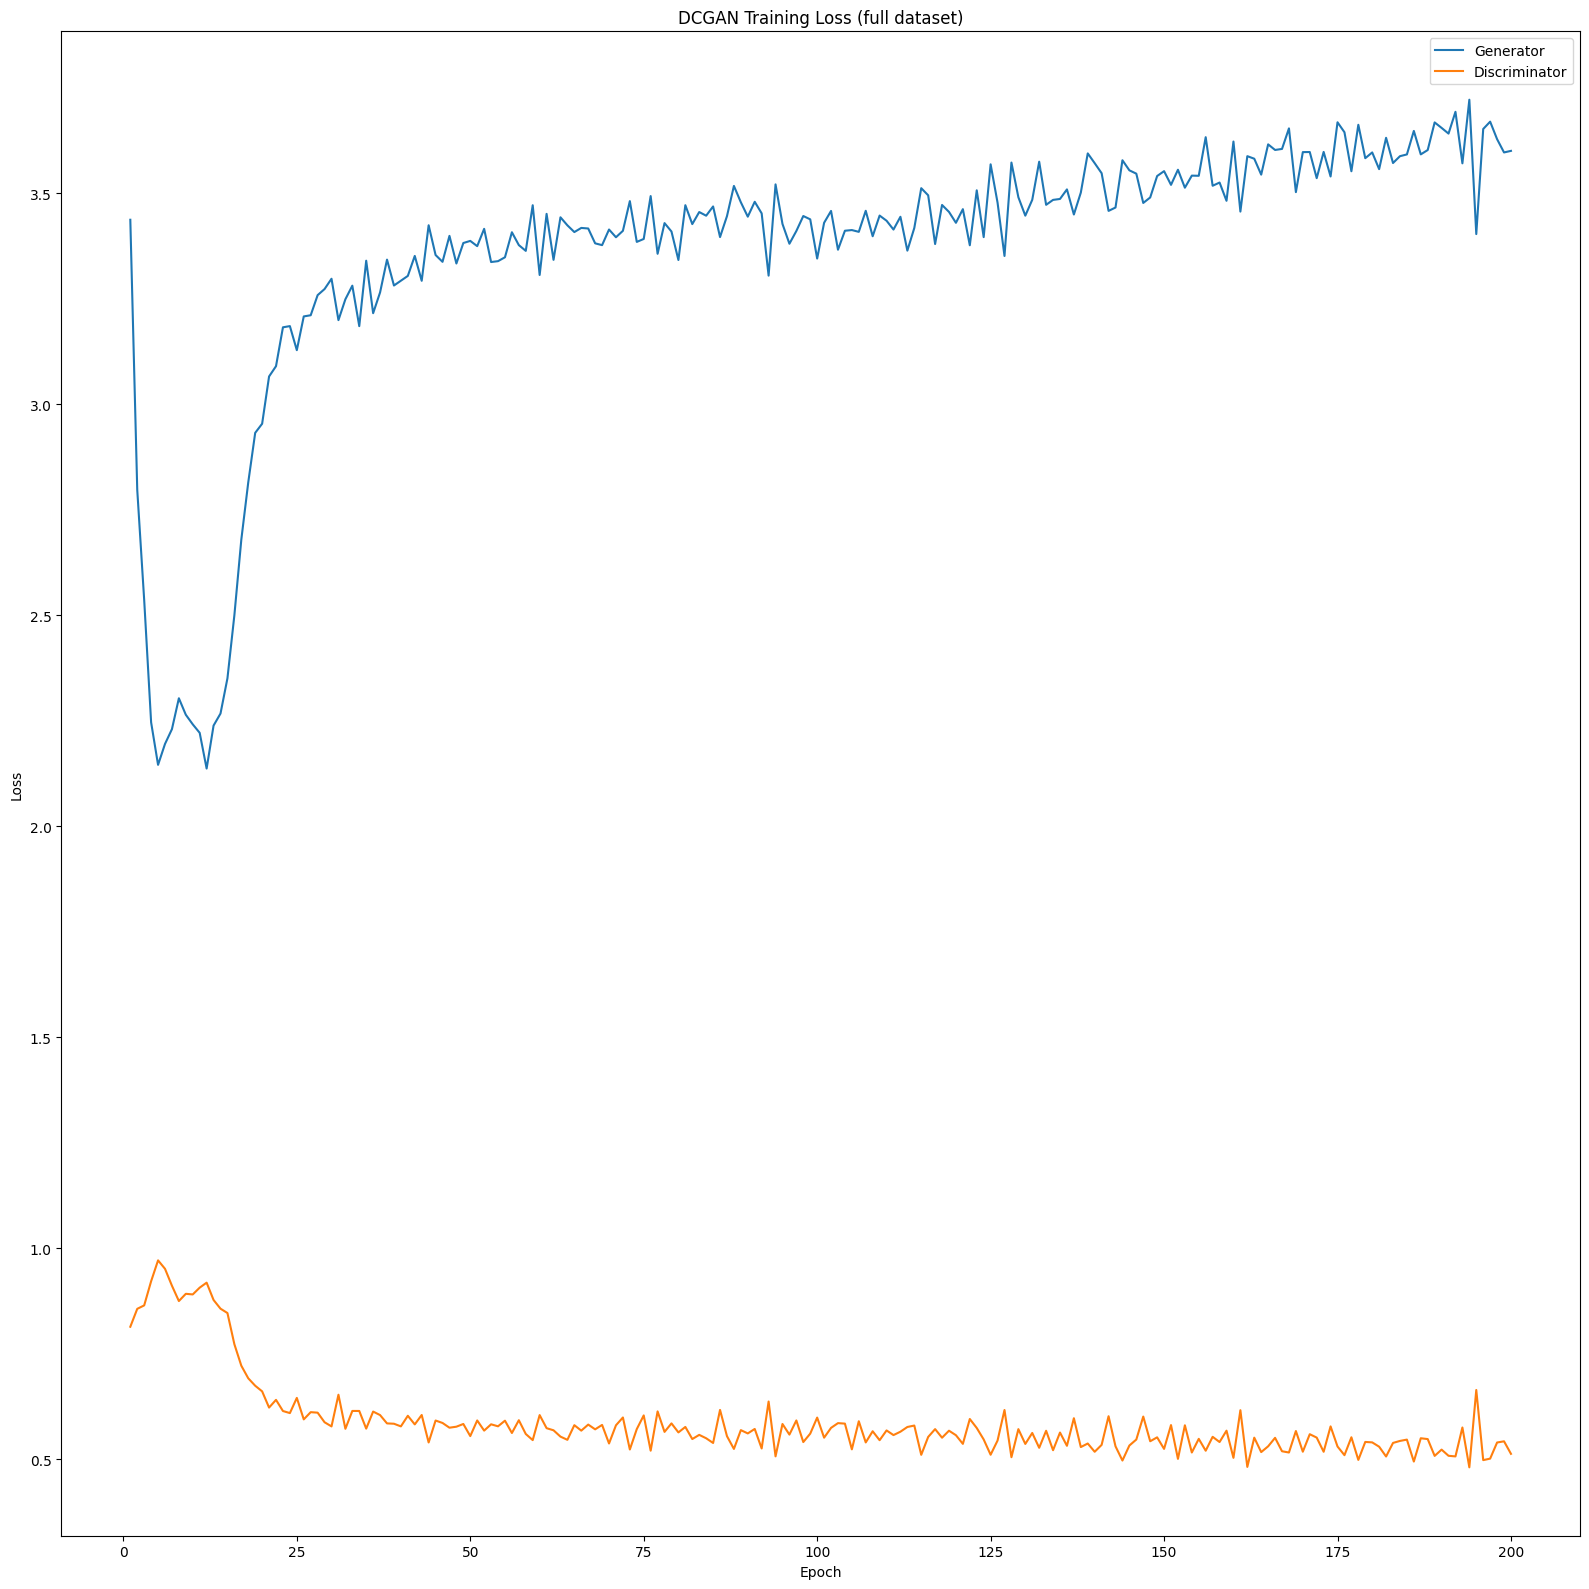

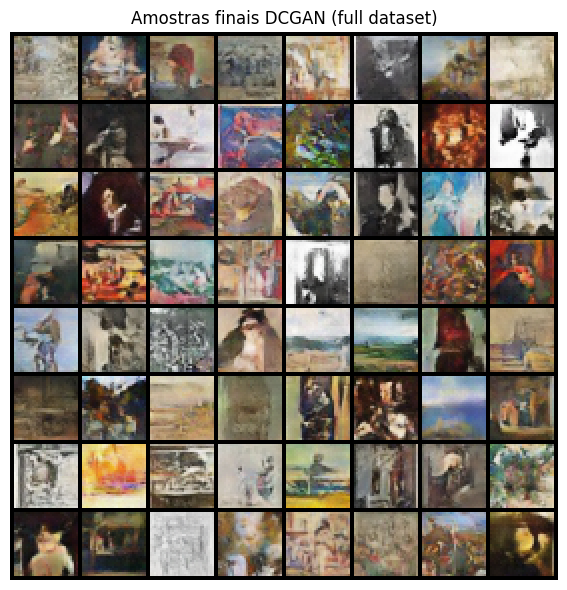

In [6]:
def show_generated(G, z, title='Amostras DCGAN'):
    G.eval()
    with torch.no_grad():
        imgs = G(z).cpu()
    # desnormaliza de [-1,1] para [0,1]
    imgs = (imgs + 1) / 2
    grid = make_grid(imgs, nrow=8)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def plot_history(history):
    epochs = range(1, len(history)+1)
    plt.figure(figsize=(16, 16))
    plt.plot(epochs, [h['loss_G'] for h in history], label='Generator')
    plt.plot(epochs, [h['loss_D'] for h in history], label='Discriminator')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('DCGAN Training Loss (full dataset)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)
show_generated(G, fixed_z, title='Amostras finais DCGAN (full dataset)')